In [1]:
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import UTILS.utils as utils
import pandas as pd

import numpy as np
import seaborn as sns

import math
#rom umap import UMAP
import plotly.express as px

In [2]:
probs = pd.read_csv("../../Data/TOPIC_MODELLING/PROBABILITY_DISTRIBUTION_SENTENCES.csv")
all_sentences = pd.read_csv("../../Data/ALL_SENTENCES_CLASSED.csv")

In [3]:
def l1_norm(matrix):
    row_sums = np.sum(matrix, axis=1, keepdims=True)
    normalized_matrix = np.copy(matrix).astype(float)
    row_sums_safe = np.where(row_sums == 0, 1, row_sums)
    normalized_matrix = normalized_matrix / row_sums_safe
    return normalized_matrix

res = l1_norm(probs.to_numpy())
probs = pd.DataFrame(data=res, columns = probs.columns)

In [4]:
topics = utils.get_list_topics()
topic_to_id = dict()
for topic in topics:
    s = all_sentences[all_sentences["paraph_class_name"] == topic]
    topic_to_id[topic] = s["paraph_class"].sample(1).values[0]
id_to_topic = {v: k for k, v in topic_to_id.items()}
id_to_topic = dict(sorted(id_to_topic.items()))

In [5]:
max_categories = 5
min_value = 0.05

In [6]:
def get_sentence_categories(row, max_categories):
    nlargest_index = list(row.nlargest(max_categories).index)
    nlargest_values = list(row.nlargest(max_categories))
    if nlargest_values[0] < min_value:
        return {"categories": [], "categories_probs":[]}
    chosen_cats = []
    values = []
    for i, index in enumerate(nlargest_index):
        if(nlargest_values[i] > min_value):
            chosen_cats.append(index)
            values.append(nlargest_values[i])
    return {"categories": chosen_cats, "categories_probs":values}
        

In [7]:
probs_applied = probs.apply(lambda x : get_sentence_categories(x, max_categories), axis=1, result_type="expand")
all_sentences = pd.concat([all_sentences, probs_applied], axis='columns')

In [8]:
all_sentences["length_cats"] = all_sentences["categories"].apply(lambda x : len(x))
c = all_sentences.groupby("length_cats")["text"].count()

In [9]:
data = pd.DataFrame(zip(c.index, c.values), columns=["Cats", "Num"])

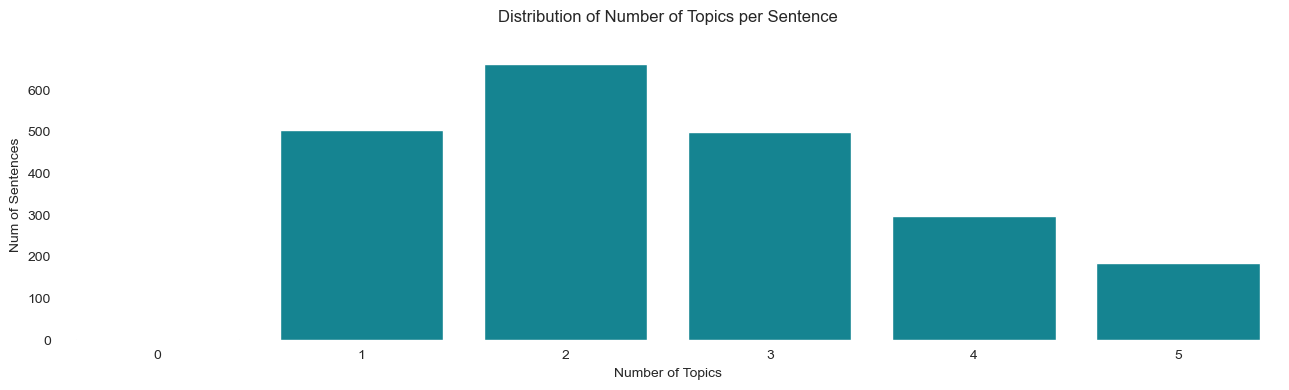

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(13, 4)) 

ax = sns.barplot(x='Cats', y='Num', data=data,
                 color='#0094a6') 

plt.xlabel('Number of Topics') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Num of Sentences')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Distribution of Number of Topics per Sentence', pad=20)

plt.tight_layout()
plt.show()

In [15]:
all_sentences.to_csv("../../Data/TOPIC_MODELLING/ALL_SENTENCES_MULTIPLE_CATEGORIES.csv", index=False)

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../../Data/TOPIC_MODELLING/ALL_SENTENCES_MULTIPLE_CATEGORIES.csv")

In [23]:
r = df[df["text"].apply(lambda x : "A strong wheelbarrow coolie will carry" in x)]

In [24]:
l = probs.iloc[r.index]

In [25]:
r["categories"].values

array(["['Transportation', 'Daily Life and Occupations', 'Trade and Commerce', 'British Colonialism', 'Social Classes and Customs']"],
      dtype=object)

In [26]:
k = list(l.iloc[0].index)
for x in range(len(k)):
    if k[x] == "Religion (Buddhism and Ancestor Worship)":
        k[x] = "Religion"

In [27]:
data = pd.DataFrame(zip(k,l.iloc[0].values), columns=["Topic", "Prob"])

In [28]:
data

,Topic,Prob
0,Agriculture and Farming,0.000000e+00
1,Architecture and Building,0.000000e+00
2,British Colonialism,2.330804e-01
3,Cemeteries and Burial Practices,0.000000e+00
4,Daily Life and Occupations,2.337451e-01
5,Education,0.000000e+00
6,Family and Social Structures,0.000000e+00
7,Fashion and Dress,0.000000e+00
8,Folk Festivals and Celebrations,0.000000e+00
9,Food and Diet,5.573607e-08


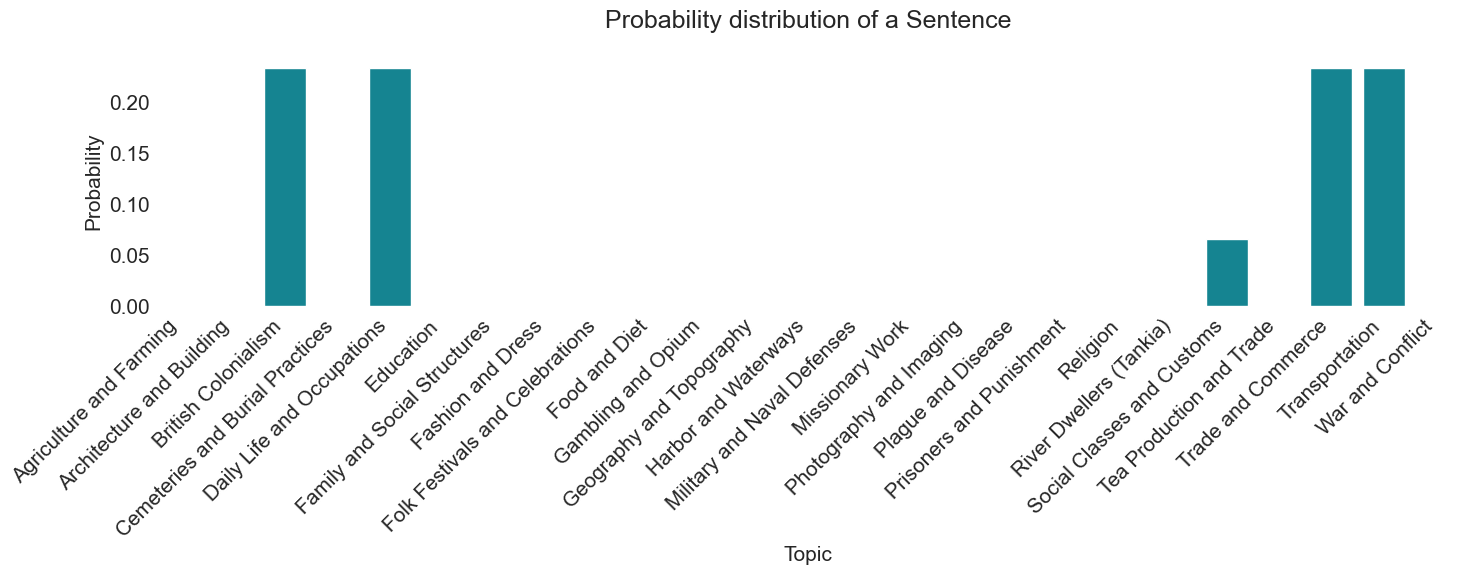

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']
plt.rcParams.update({'font.size': 15})

sns.set_style("white") 
plt.figure(figsize=(15, 6)) 

ax = sns.barplot(x='Topic', y='Prob', data=data,
                 #order=topic_order,
                 color='#0094a6') 

plt.xlabel('Topic') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Probability')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Probability distribution of a Sentence', pad=20)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [27]:
r = all_sentences[all_sentences["text"].apply(lambda x : "A strong wheelbarrow coolie will carry" in x)]